In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-detuning-filter',
        '--data_dir', '../../data/kalman',
        '--data_file', 'tesla_sim',
        '--data_nsample', '500',
        '--data_train_size', '0.8',
        '--data_test_size', '0.5',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/kalman/filter',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 3, "cos": 3}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '64',
        '--nlayer_stat', '2',
        '--nneuron_trans', '128',
        '--nlayer_trans', '3',
    ]
)

In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.791536, valid=0.234906, test=0.246833
	validation loss decreased (inf -> 0.234906), saving model ...
	epoch 2 losses: train=0.803616, valid=0.067757, test=0.067371
	validation loss decreased (0.234906 -> 0.067757), saving model ...
	epoch 3 losses: train=0.713278, valid=0.065547, test=0.065579
	validation loss decreased (0.067757 -> 0.065547), saving model ...
	epoch 4 losses: train=0.680830, valid=0.062226, test=0.061947
	validation loss decreased (0.065547 -> 0.062226), saving model ...
	epoch 5 losses: train=0.634880, valid=0.067117, test=0.069658
	early stopping counter: 1 out of 10
	epoch 6 losses: train=0.434906, valid=0.041375, test=0.039390
	validation loss decreased (0.062226 -> 0.041375), saving model ...
	epoch 7 losses: train=0.270593, valid=0.026243, test=0.025419
	validation loss decreased (0.041375 -> 0.026243), saving model ...
	epoch 8 losses: train=0.243442, valid=0.022594, test=0.022312
	validation loss decreased

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

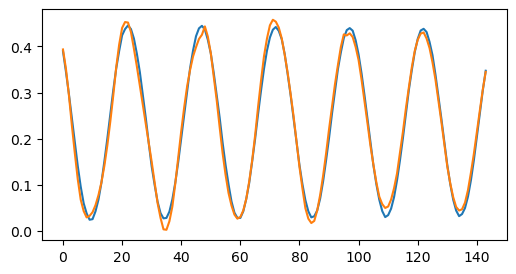

In [6]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break